# Librerías


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Datos

In [ ]:
df = pd.read_csv('datos.csv')

In [ ]:
df.head()

,Lote,Semana_prod,Peso_gr,Muertos,Descartes,Iniciador_bolsas,Terminador_bolsas
0,1,1,118,84,0,42,0
1,1,2,198,38,0,85,0
2,1,3,439,35,0,106,0
3,1,4,746,18,0,59,55
4,1,5,1101,21,0,0,172


# Objetivo del modelo


Desarrollar un sistema predictivo capaz de estimar la evolución productiva de un lote de pollos de engorde, anticipando:

- Peso semanal esperado.
- Consumo de alimento iniciador.
- Consumo de alimento terminador.
- Mortalidad acumulada.
- Desvíos respecto a la proyección.

El foco principal del sistema es mejorar la planificación productiva y la estimación temprana de costos asociados al alimento.


# Variables usadas


Para el modelo principal se usa como variable objetivo:

- **`Peso_gr`**: peso promedio del lote en gramos para cada semana.

Variables predictoras del modelo de peso:

- **`Semana_prod`**: semana productiva. Captura la etapa de crecimiento del pollo.
- **`Muertos_acum`**: mortalidad acumulada hasta la semana. Resume el impacto sanitario/productivo del lote.
- **`Descartes_acum`**: descartes acumulados. Ayuda a medir pérdidas por calidad o condición de aves.
- **`Aves_vivas`**: aves estimadas en producción. Se calcula restando muertos y descartes al stock inicial.
- **`Peso_anterior`**: peso de la semana previa. Es la referencia más fuerte para proyectar el crecimiento siguiente.
- **`Dias`**: días acumulados de producción, calculados como semana por 7.

El número de **`Lote`** no se usa como predictor directo para evitar que el modelo memorice un lote específico. Se utiliza para ordenar los datos, calcular acumulados y comparar resultados por lote.


# Tipo de modelo


Para este proyecto se utilizaron modelos de **Machine Learning supervisado basados en Random Forest Regressor**.

Random Forest es un algoritmo de ensamble que combina múltiples árboles de decisión para realizar predicciones más robustas y reducir el riesgo de sobreajuste.

Se seleccionó este enfoque porque:

* Funciona adecuadamente con conjuntos de datos pequeños y medianos.
* Captura relaciones no lineales entre las variables productivas.
* Tolera variables correlacionadas sin requerir transformaciones complejas.
* Requiere poca preparación de datos en comparación con otros modelos.
* Permite generar predicciones estables para escenarios productivos reales.

En la solución actual se entrenan tres modelos independientes:
1. Modelo de predicción de peso promedio.
2. Modelo de predicción de consumo de alimento iniciador.
3. Modelo de predicción de consumo de alimento terminador.


# Tratamiento de variables

In [ ]:
# Ordenar por lote y semana
df = df.sort_values(['Lote', 'Semana_prod'])

# Mortalidad acumulada por lote
df['Muertos_acum'] = df.groupby('Lote')['Muertos'].cumsum()

# Descartes acumulados
df['Descartes_acum'] = df.groupby('Lote')['Descartes'].cumsum()

# Aves vivas (asumiendo 4200 iniciales)
# Usaremos 4200 como constante para todos los lotes (ajustar si es diferente)
aves_iniciales = 4200
df['Aves_vivas'] = aves_iniciales - df['Muertos_acum'] - df['Descartes_acum']

# Peso anterior (lag 1)
df['Peso_anterior'] = df.groupby('Lote')['Peso_gr'].shift(1)

# Consumo iniciador anterior
df['Iniciador_anterior'] = df.groupby('Lote')['Iniciador_bolsas'].shift(1)

# Consumo terminador anterior
df['Terminador_anterior'] = df.groupby('Lote')['Terminador_bolsas'].shift(1)

# Días de producción: usamos una variable 'días' que acumule 7 por semana
df['Dias'] = df['Semana_prod'] * 7

# Eliminar filas sin peso anterior (primera semana de cada lote)
df_modelo = df.dropna(subset=['Peso_anterior']).copy()


# Modelo 1: prediccion de peso semanal


In [ ]:
# Variables predictoras del modelo principal
features_peso = ['Semana_prod', 'Muertos_acum', 'Descartes_acum', 'Aves_vivas', 'Peso_anterior', 'Dias']
X_peso = df_modelo[features_peso]
y_peso = df_modelo['Peso_gr']

# Entrenamiento del modelo
rf_peso = RandomForestRegressor(n_estimators=100, random_state=42)
rf_peso.fit(X_peso, y_peso)

# Evaluación dentro de la muestra histórica
pred_peso = rf_peso.predict(X_peso)
df_modelo['Peso_pred'] = pred_peso
df_modelo['Error_gr'] = df_modelo['Peso_gr'] - df_modelo['Peso_pred']

mae_peso = mean_absolute_error(y_peso, pred_peso)
rmse_peso = np.sqrt(mean_squared_error(y_peso, pred_peso))
r2_peso = r2_score(y_peso, pred_peso)


print(f"MAE peso: {mae_peso:.2f} g")
print(f"RMSE peso: {rmse_peso:.2f} g")
print(f"R2 peso: {r2_peso:.3f}")


MAE peso: 62.34 g
RMSE peso: 87.59 g
R2 peso: 0.996


**Lectura de resultados del modelo de peso**

- **MAE**: indica el error promedio en gramos. Si el MAE es bajo, el modelo se equivoca poco en una semana típica.
- **RMSE**: también mide error, pero castiga más los errores grandes. Sirve para ver si hay semanas donde el modelo se aleja demasiado.
- **R2**: mide qué tan bien el modelo reproduce la variación observada en los pesos históricos. Valores cercanos a 1 indican mejor ajuste.

Estos resultados deben interpretarse como una primera validación sobre los datos disponibles. Como hay pocos lotes históricos, el modelo puede verse muy preciso dentro de la muestra, pero conviene validarlo con nuevos lotes antes de usarlo como única referencia de decisión.


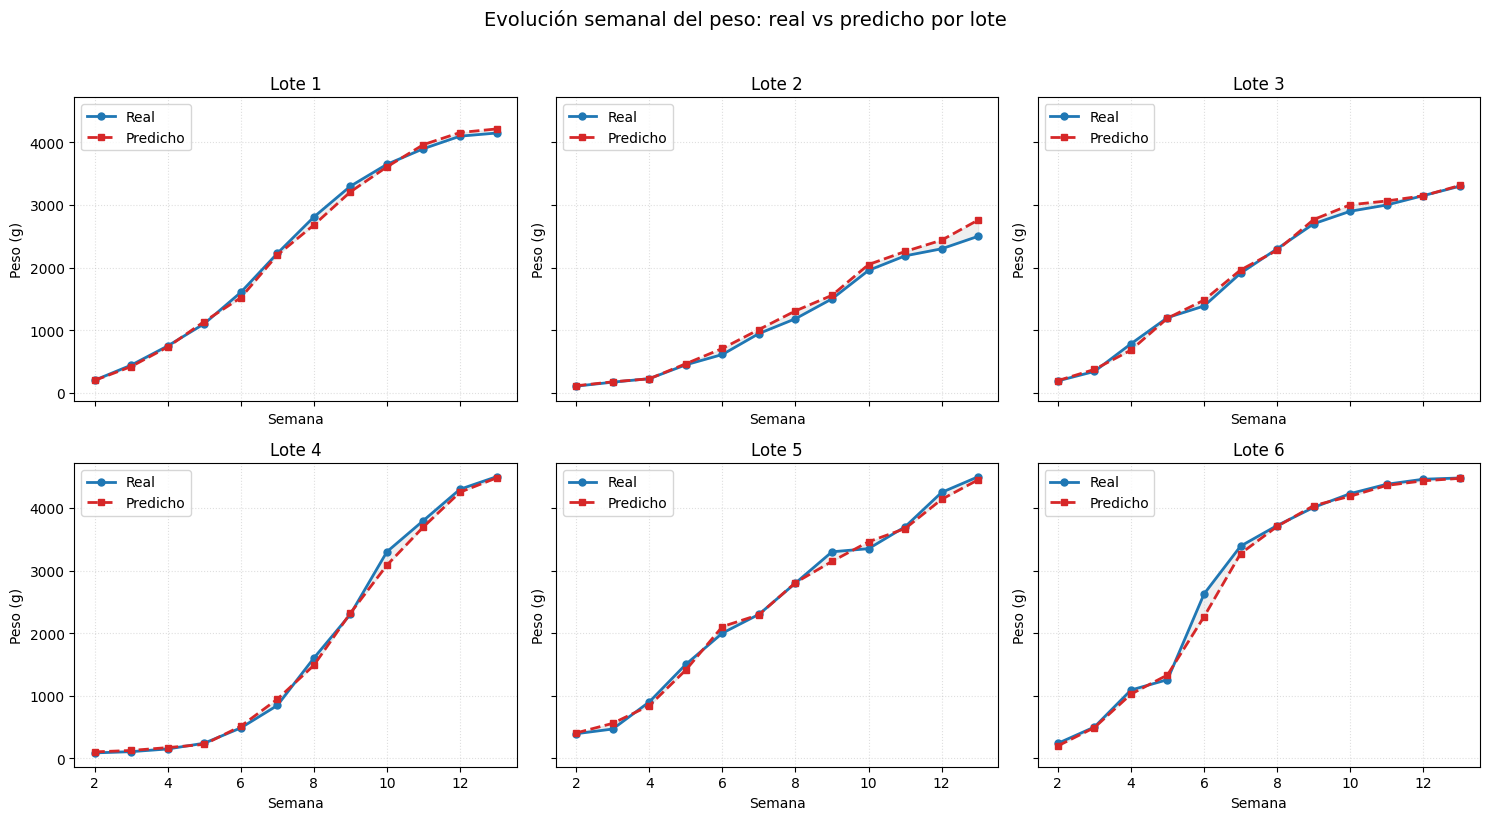

In [ ]:
lotes = sorted(df_modelo['Lote'].unique())
n_lotes = len(lotes)
ncols = 3
nrows = (n_lotes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, lote in enumerate(lotes):
    subset = df_modelo[df_modelo['Lote'] == lote]
    ax = axes[i]
    ax.plot(subset['Semana_prod'], subset['Peso_gr'], 'o-', color='#1f77b4', linewidth=2, markersize=5, label='Real')
    ax.plot(subset['Semana_prod'], subset['Peso_pred'], 's--', color='#d62728', linewidth=2, markersize=5, label='Predicho')
    ax.fill_between(subset['Semana_prod'], subset['Peso_gr'], subset['Peso_pred'], color='gray', alpha=0.12)
    ax.set_title(f'Lote {lote}')
    ax.set_xlabel('Semana')
    ax.set_ylabel('Peso (g)')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper left')

for j in range(len(lotes), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Evolución semanal del peso: real vs predicho por lote', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Interpretación de la evolución semanal del peso por lote (real vs. predicho)**

- **Qué representa:** Este gráfico permite analizar el desempeño individual de cada lote histórico de manera secuencial a lo largo de las semanas de producción. La línea azul con círculos (`Real`) indica el peso real observado, mientras que la línea roja discontinua con cuadrados (`Predicho`) muestra la estimación calculada por el modelo. El área sombreada en gris resalta la magnitud del error o diferencia entre el valor real y la predicción en cada semana.
- **Cómo interpretarlo:**
  - **Líneas superpuestas o muy cercanas (sombreado mínimo):** El modelo predice con alta precisión el crecimiento de ese lote, logrando capturar correctamente su tendencia y velocidad de ganancia de peso.
  - **Separación entre líneas (sombreado amplio):** Señala desviaciones en las que el lote real creció por encima o por debajo de lo esperado. Estas diferencias permiten identificar retrospectivamente semanas con anomalías de manejo, cambios repentinos de alimento, densidad excesiva de aves, problemas de salud o factores ambientales (como estrés térmico) que afectaron el rendimiento habitual.


# Modelo 2: consumo de iniciador y terminador

El sistema incluye dos modelos específicos para estimar el consumo de alimento durante el ciclo productivo.

* **Modelo de Iniciador**:
Entrenado únicamente con semanas donde existe consumo de alimento iniciador.

* **Modelo de Terminador**:
Entrenado únicamente con semanas donde existe consumo de alimento terminador.

Ambos modelos utilizan información productiva del lote, incluyendo semana de producción, peso promedio, mortalidad acumulada y cantidad de aves vivas.

El objetivo es **anticipar necesidades de alimento y apoyar la planificación operativa**. Debido a que el consumo real también puede verse afectado por factores externos como manejo, disponibilidad de alimento, condiciones ambientales y estrategias de producción, las predicciones deben interpretarse como una herramienta de apoyo para la toma de decisiones y no como una orden automática de compra.

In [ ]:
# Iniciador: semanas donde se registra consumo de alimento iniciador
features_cons = ['Semana_prod', 'Peso_gr', 'Muertos_acum', 'Aves_vivas']

df_iniciador = df_modelo[df_modelo['Iniciador_bolsas'] > 0].copy()
X_ini = df_iniciador[features_cons]
y_ini = df_iniciador['Iniciador_bolsas']
rf_ini = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ini.fit(X_ini, y_ini)

# Terminador: semanas donde se registra consumo de alimento terminador
df_terminador = df_modelo[df_modelo['Terminador_bolsas'] > 0].copy()
X_ter = df_terminador[features_cons]
y_ter = df_terminador['Terminador_bolsas']
rf_ter = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ter.fit(X_ter, y_ter)

print('Modelos de consumo entrenados: iniciador y terminador')


Modelos de consumo entrenados: iniciador y terminador


# Simulación para un lote nuevo - Sin datos del lote en producción




In [ ]:
def predecir_lote_nuevo(
    semanas=13,
    aves_iniciales=4000,
    peso_inicial=None,
    muertos_estimados=None,
    descartes_estimados=None
):
    """
    Proyecta semana a semana el peso y consumo esperado de un lote nuevo.

    Parámetros
    ----------
    semanas : int
        Cantidad de semanas a proyectar.

    aves_iniciales : int
        Cantidad inicial de aves del lote.

    peso_inicial : float o None
        Peso real de la semana 1.
        Si es None se utiliza el promedio histórico.

    muertos_estimados : lista o None
        Muertos esperados por semana.
        Si es None se utilizan promedios históricos.

    descartes_estimados : lista o None
        Descartes esperados por semana.
        Si es None se utilizan promedios históricos.
    """

    # Semana de transición entre iniciador y terminador
    SEMANA_CORTE_ALIMENTO = 4 #VARIABLE A MODIFICAR

    # Promedios históricos por semana
    if muertos_estimados is None:
        muertos_estimados = (
            df.groupby('Semana_prod')['Muertos']
            .mean()
            .reindex(range(1, semanas + 1))
            .ffill()
            .fillna(0)
            .values
        )

    if descartes_estimados is None:
        descartes_estimados = (
            df.groupby('Semana_prod')['Descartes']
            .mean()
            .reindex(range(1, semanas + 1))
            .ffill()
            .fillna(0)
            .values
        )

    # Peso inicial
    if peso_inicial is None:
        peso_inicial = (
            df.loc[df['Semana_prod'] == 1, 'Peso_gr']
            .mean()
        )

    peso_actual = peso_inicial

    muertos_acum = 0
    desc_acum = 0

    resultados = []

    for semana in range(1, semanas + 1):

        aves_vivas = int(round(
            aves_iniciales - muertos_acum - desc_acum
        ))

        peso_anterior = (
            peso_inicial
            if semana == 1
            else peso_actual
        )

        # Predicción de peso
        X_pred = pd.DataFrame(
            [[
                semana,
                muertos_acum,
                desc_acum,
                aves_vivas,
                peso_anterior,
                semana * 7
            ]],
            columns=features_peso
        )

        peso_pred = rf_peso.predict(X_pred)[0]
        peso_actual = peso_pred

        # Predicción de consumo
        X_cons = pd.DataFrame(
            [[
                semana,
                peso_pred,
                muertos_acum,
                aves_vivas
            ]],
            columns=features_cons
        )

        ini_pred = (
            rf_ini.predict(X_cons)[0]
            if semana <= SEMANA_CORTE_ALIMENTO
            else 0
        )

        ter_pred = (
            rf_ter.predict(X_cons)[0]
            if semana >= SEMANA_CORTE_ALIMENTO
            else 0
        )

        # Acumulados actualizados para mostrar en la tabla
        muertos_acum_mostrar = (
            muertos_acum +
            muertos_estimados[semana - 1]
        )

        desc_acum_mostrar = (
            desc_acum +
            descartes_estimados[semana - 1]
        )

        resultados.append({
            'Semana': semana,
            'Peso_gr': round(peso_pred, 2),

            'Muertos_semana': muertos_estimados[semana - 1],
            'Descartes_semana': descartes_estimados[semana - 1],

            'Muertos_acum': round(muertos_acum_mostrar, 0),
            'Descartes_acum': round(desc_acum_mostrar, 0),

            'Aves_vivas': aves_vivas,

            'Iniciador_bolsas': round(max(0, ini_pred), 2),
            'Terminador_bolsas': round(max(0, ter_pred), 2)
        })

        # Actualizar acumulados para la siguiente semana
        muertos_acum += muertos_estimados[semana - 1]
        desc_acum += descartes_estimados[semana - 1]

    return pd.DataFrame(resultados)

In [ ]:
prediccion = predecir_lote_nuevo(
    aves_iniciales=4228,
    peso_inicial=100.6,

)

prediccion_mostrar = prediccion.copy()
prediccion_mostrar['Peso_gr'] = prediccion_mostrar['Peso_gr'].round(0).astype(int)
prediccion_mostrar['Iniciador_bolsas'] = prediccion_mostrar['Iniciador_bolsas'].round(1)
prediccion_mostrar['Terminador_bolsas'] = prediccion_mostrar['Terminador_bolsas'].round(1)

prediccion_mostrar[
    [
        'Semana',
        'Peso_gr',
        'Muertos_acum',
        'Descartes_acum',
        'Aves_vivas',
        'Iniciador_bolsas',
        'Terminador_bolsas'
    ]
]


,Semana,Peso_gr,Muertos_acum,Descartes_acum,Aves_vivas,Iniciador_bolsas,Terminador_bolsas
0,1,182,70.0,5.0,4228,44.5,0.0
1,2,305,110.0,13.0,4153,50.4,0.0
2,3,536,148.0,29.0,4105,74.8,0.0
3,4,1001,178.0,37.0,4051,83.0,112.4
4,5,1342,189.0,43.0,4013,0.0,156.8
5,6,2144,239.0,56.0,3996,0.0,164.5
6,7,2418,265.0,61.0,3933,0.0,207.7
7,8,2823,300.0,69.0,3902,0.0,214.2
8,9,3139,387.0,73.0,3859,0.0,151.7
9,10,3357,415.0,80.0,3768,0.0,104.8


**Cómo funciona la predicción del lote nuevo**

La proyección se calcula semana por semana. Primero se estima el peso usando la información disponible para esa semana: semana productiva, aves vivas, muertos acumulados, descartes acumulados, días de producción y peso anterior.

Después, el peso predicho se usa como insumo para estimar consumo de iniciador o terminador. Para mortalidad y descartes, si no se carga un escenario propio, el notebook usa el promedio histórico por semana. Por eso la predicción representa un lote nuevo con comportamiento similar al promedio de los lotes anteriores.


# Prediccion para un lote nuevo - Con datos del lote en producción

Para cada nueva semana, agrego una fila y vuelvo a ejecutar la celta de `actualizar_proyeccion`

In [ ]:
lote_actual = pd.DataFrame({
    "Semana_prod": [1, 2, 3],
    "Peso_gr": [100.6, 226.6, 575.8],
    "Muertos_acum": [45, 57, 86],
    "Descartes_acum": [1, 11, 21],
    "Iniciador_bolsas":[26, 67, 90],
    "Terminador_bolsas":[0, 0, 0]
})

In [ ]:
SEMANA_CORTE_ALIMENTO = 4

def actualizar_proyeccion(
    lote_actual,
    rf_peso,
    rf_iniciador,
    rf_terminador,
    aves_iniciales=4228,
    semanas_totales=13
):

    resultados = []

    # Copiamos las semanas reales
    for _, fila in lote_actual.iterrows():

      aves_vivas = (
          aves_iniciales
          - fila["Muertos_acum"]
          - fila["Descartes_acum"]
      )

      resultados.append({
          "Semana_prod": fila["Semana_prod"],
          "Peso_gr": fila["Peso_gr"],

          "Muertos_acum": fila["Muertos_acum"],
          "Descartes_acum": fila["Descartes_acum"],
          "Aves_vivas": aves_vivas,

          "Iniciador_bolsas": fila.get(
              "Iniciador_bolsas",
              np.nan
          ),

          "Terminador_bolsas": fila.get(
              "Terminador_bolsas",
              np.nan
          ),

          "Tipo": "REAL"
      })

    ultima = lote_actual.iloc[-1]

    semana_actual = int(ultima["Semana_prod"])
    peso_actual = float(ultima["Peso_gr"])
    muertos_acum = float(ultima["Muertos_acum"])
    descartes_acum = float(ultima["Descartes_acum"])

    aves_vivas = (
        aves_iniciales
        - muertos_acum
        - descartes_acum
    )

    # Promedios históricos por semana
    prom_muertos_semana = (
        df.groupby("Semana_prod")["Muertos"]
        .mean()
    )

    prom_descartes_semana = (
        df.groupby("Semana_prod")["Descartes"]
        .mean()
    )

    for semana in range(
        semana_actual + 1,
        semanas_totales + 1
    ):

        muertos_semana = prom_muertos_semana.get(
            semana,
            prom_muertos_semana.iloc[-1]
        )

        descartes_semana = prom_descartes_semana.get(
            semana,
            prom_descartes_semana.iloc[-1]
        )

        muertos_acum += muertos_semana
        descartes_acum += descartes_semana

        aves_vivas = (
            aves_iniciales
            - muertos_acum
            - descartes_acum
        )

        dias = semana * 7

        X_peso_nuevo = pd.DataFrame([{
            "Semana_prod": semana,
            "Muertos_acum": muertos_acum,
            "Descartes_acum": descartes_acum,
            "Aves_vivas": aves_vivas,
            "Peso_anterior": peso_actual,
            "Dias": dias
        }])

        peso_pred = rf_peso.predict(X_peso_nuevo)[0]

        X_alimento = pd.DataFrame([{
            "Semana_prod": semana,
            "Peso_gr": peso_pred,
            "Muertos_acum": muertos_acum,
            "Aves_vivas": aves_vivas
        }])

        iniciador = (
            rf_iniciador.predict(X_alimento)[0]
            if semana <= SEMANA_CORTE_ALIMENTO
            else 0
        )

        terminador = (
            rf_terminador.predict(X_alimento)[0]
            if semana >= SEMANA_CORTE_ALIMENTO
            else 0
        )

        resultados.append({
            "Semana_prod": semana,
            "Peso_gr": round(peso_pred, 2),
            "Muertos_acum": round(muertos_acum, 0),
            "Descartes_acum": round(descartes_acum, 0),
            "Aves_vivas": round(aves_vivas, 0),
            "Iniciador_bolsas": round(max(0, iniciador), 2),
            "Terminador_bolsas": round(max(0, terminador), 2),
            "Tipo": "PROYECTADO"
        })

        peso_actual = peso_pred

    return pd.DataFrame(resultados)

In [ ]:
forecast = actualizar_proyeccion(
    lote_actual,
    rf_peso,
    rf_ini,
    rf_ter
)

In [ ]:
forecast

,Semana_prod,Peso_gr,Muertos_acum,Descartes_acum,Aves_vivas,Iniciador_bolsas,Terminador_bolsas,Tipo
0,1.0,100.60,45.0,1.0,4182.0,26.00,0.00,REAL
1,2.0,226.60,57.0,11.0,4160.0,67.00,0.00,REAL
2,3.0,575.80,86.0,21.0,4121.0,90.00,0.00,REAL
3,4.0,1030.58,115.0,30.0,4083.0,76.55,82.44,PROYECTADO
4,5.0,1369.06,127.0,35.0,4066.0,0.00,102.81,PROYECTADO
5,6.0,2177.60,177.0,48.0,4003.0,0.00,148.53,PROYECTADO
6,7.0,2461.99,203.0,53.0,3972.0,0.00,148.76,PROYECTADO
7,8.0,2828.40,238.0,61.0,3929.0,0.00,197.21,PROYECTADO
8,9.0,3249.43,325.0,65.0,3838.0,0.00,145.31,PROYECTADO
9,10.0,3607.11,353.0,72.0,3802.0,0.00,94.09,PROYECTADO


# Errores

La siguiente tabla muestra la comparación entre los valores reales y los valores predichos por los modelos. Para cada semana evaluada se calculan los errores de predicción, permitiendo analizar el grado de precisión de las estimaciones de peso y consumo de alimento.

In [ ]:
def calcular_errores_lote(
    lote_actual,
    rf_peso,
    rf_ini,
    rf_ter,
    features_peso,
    features_cons,
    aves_iniciales
):

    lote_eval = lote_actual.copy()

    # Variables necesarias para el modelo de peso
    lote_eval["Aves_vivas"] = (
        aves_iniciales
        - lote_eval["Muertos_acum"]
        - lote_eval["Descartes_acum"]
    )

    lote_eval["Dias"] = (
        lote_eval["Semana_prod"] * 7
    )

    lote_eval["Peso_anterior"] = (
        lote_eval["Peso_gr"]
        .shift(1)
    )

    # Primera semana no puede evaluarse porque no existe Peso_anterior
    lote_eval = lote_eval.dropna(
        subset=["Peso_anterior"]
    ).copy()

    if lote_eval.empty:

        return pd.DataFrame()

    # Predicción de peso
    lote_eval["Peso_Predicho"] = np.round(
        rf_peso.predict(
            lote_eval[features_peso]
        ),
        2
    )

    # Predicción de iniciador
    lote_eval["Iniciador_Predicho"] = np.round(
        rf_ini.predict(
            lote_eval[features_cons]
        ),
        2
    )

    # Predicción de terminador
    lote_eval["Terminador_Predicho"] = np.round(
        rf_ter.predict(
            lote_eval[features_cons]
        ),
        2
    )

    # Errores peso
    lote_eval["Error_Peso_g"] = np.round(
        lote_eval["Peso_gr"]
        - lote_eval["Peso_Predicho"],
        2
    )

    lote_eval["Abs_Error_Peso_g"] = np.round(
        lote_eval["Error_Peso_g"].abs(),
        2
    )

    lote_eval["Error_Peso_pct"] = np.round(
        (
            lote_eval["Error_Peso_g"]
            / lote_eval["Peso_Predicho"]
        ) * 100,
        2
    )

    # Errores iniciador
    lote_eval["Error_Iniciador"] = np.round(
        lote_eval["Iniciador_bolsas"]
        - lote_eval["Iniciador_Predicho"],
        2
    )

    # Errores terminador
    lote_eval["Error_Terminador"] = np.round(
        lote_eval["Terminador_bolsas"]
        - lote_eval["Terminador_Predicho"],
        2
    )

    return lote_eval[
        [
            "Semana_prod",

            "Peso_gr",
            "Peso_Predicho",
            "Error_Peso_g",
            "Abs_Error_Peso_g",
            "Error_Peso_pct",

            "Iniciador_bolsas",
            "Iniciador_Predicho",
            "Error_Iniciador",

            "Terminador_bolsas",
            "Terminador_Predicho",
            "Error_Terminador"
        ]
    ]

In [ ]:
errores_lote = calcular_errores_lote(
    lote_actual,
    rf_peso,
    rf_ini,
    rf_ter,
    features_peso,
    features_cons,
    aves_iniciales
)

errores_lote

,Semana_prod,Peso_gr,Peso_Predicho,Error_Peso_g,Abs_Error_Peso_g,Error_Peso_pct,Iniciador_bolsas,Iniciador_Predicho,Error_Iniciador,Terminador_bolsas,Terminador_Predicho,Error_Terminador
1,2,226.6,182.34,44.26,44.26,24.27,67,45.49,21.51,0,19.21,-19.21
2,3,575.8,430.35,145.45,145.45,33.80,90,73.01,16.99,0,51.91,-51.91


# Metricas de evaluación

Se calculan métricas de error para las predicciones de peso y consumo de alimento utilizando los datos reales disponibles del lote. Estas métricas permiten cuantificar la precisión de las estimaciones realizadas por los modelos y facilitar la comparación entre valores observados y proyectados.

In [ ]:
if not errores_lote.empty:

    # =====================
    # MÉTRICAS DE PESO
    # =====================

    mae_peso = errores_lote["Abs_Error_Peso_g"].mean()

    rmse_peso = np.sqrt(
        np.mean(
            errores_lote["Error_Peso_g"] ** 2
        )
    )

    mape_peso = np.mean(
        np.abs(
            errores_lote["Error_Peso_pct"]
        )
    )

    # =====================
    # MÉTRICAS INICIADOR
    # =====================

    mae_ini = np.mean(
        np.abs(
            errores_lote["Error_Iniciador"]
        )
    )

    mape_ini = np.mean(
        np.abs(
            (
                errores_lote["Error_Iniciador"]
                / errores_lote["Iniciador_bolsas"]
            ).replace(
                [np.inf, -np.inf],
                np.nan
            )
        )
    ) * 100

    # =====================
    # MÉTRICAS TERMINADOR
    # =====================

    mae_ter = np.mean(
        np.abs(
            errores_lote["Error_Terminador"]
        )
    )

    mape_ter = np.mean(
        np.abs(
            (
                errores_lote["Error_Terminador"]
                / errores_lote["Terminador_bolsas"]
            ).replace(
                [np.inf, -np.inf],
                np.nan
            )
        )
    ) * 100

    # =====================
    # TABLA RESUMEN
    # =====================

    metricas_lote = pd.DataFrame({

        "Indicador": [
            "Semanas evaluadas",

            "MAE Peso (g)",
            "RMSE Peso (g)",
            "MAPE Peso (%)",

            "MAE Iniciador (bolsas)",
            "MAPE Iniciador (%)",

            "MAE Terminador (bolsas)",
            "MAPE Terminador (%)"
        ],

        "Valor": [
            len(errores_lote),

            round(mae_peso, 2),
            round(rmse_peso, 2),
            round(mape_peso, 2),

            round(mae_ini, 2),
            round(mape_ini, 2),

            round(mae_ter, 2),
            round(mape_ter, 2)
        ]
    })

    display(metricas_lote)

else:

    print(
        "No hay suficientes datos para calcular métricas."
    )

,Indicador,Valor
0,Semanas evaluadas,2.00
1,MAE Peso (g),94.85
2,RMSE Peso (g),107.51
3,MAPE Peso (%),29.03
4,MAE Iniciador (bolsas),19.25
5,MAPE Iniciador (%),25.49
6,MAE Terminador (bolsas),35.56
7,MAPE Terminador (%),NaN


## Interpretación de las métricas

Estas métricas permiten evaluar qué tan precisas son las predicciones realizadas por los modelos de peso y consumo de alimento. Cuanto menores sean los errores, mejor será el desempeño del modelo. Las métricas se calculan comparando los valores predichos con los valores reales observados en el lote.

### Descripción de las métricas

| Métrica | Descripción | Interpretación |
|----------|----------|----------|
| **MAE (Mean Absolute Error)** | Promedio del error absoluto entre el valor real y el predicho. | Indica cuánto se equivoca el modelo en promedio. Por ejemplo, un MAE de 50 g significa que las predicciones de peso se desvían en promedio 50 gramos del valor real. |
| **RMSE (Root Mean Squared Error)** | Similar al MAE, pero penaliza más los errores grandes. | Permite detectar si existen semanas con errores particularmente elevados. Cuanto menor sea, mejor. |
| **MAPE (Mean Absolute Percentage Error)** | Error promedio expresado como porcentaje del valor real. | Facilita interpretar la precisión del modelo independientemente de la unidad utilizada. Por ejemplo, un MAPE de 5% indica que el error promedio representa aproximadamente un 5% del valor real. |
| **Semanas evaluadas** | Cantidad de semanas reales utilizadas para calcular las métricas. | A mayor cantidad de semanas evaluadas, más representativa será la evaluación del modelo. |

### Guía rápida de interpretación del MAPE

| MAPE | Interpretación |
|--------|--------|
| **Menor a 5%** | Excelente precisión |
| **Entre 5% y 10%** | Muy buena precisión |
| **Entre 10% y 20%** | Precisión aceptable |
| **Entre 20% y 30%** | Precisión moderada |
| **Mayor a 30%** | El modelo requiere mejoras o más datos |

# Mensaje semanal

In [ ]:
ultima_real = forecast[forecast["Tipo"] == "REAL"].iloc[-1]

semana_actual = int(ultima_real["Semana_prod"])

peso_real = ultima_real["Peso_gr"]
muertos_real = int(ultima_real["Muertos_acum"])
descartes_real = int(ultima_real["Descartes_acum"])
aves_vivas_real = int(ultima_real["Aves_vivas"])

proxima = forecast[
    forecast["Semana_prod"] == semana_actual + 1
]

if len(proxima) > 0:

    proxima = proxima.iloc[0]

    peso_prox = proxima["Peso_gr"]
    ini_prox = proxima["Iniciador_bolsas"]
    ter_prox = proxima["Terminador_bolsas"]

    muertos_prox = int(proxima["Muertos_acum"])
    descartes_prox = int(proxima["Descartes_acum"])
    aves_vivas_prox = int(proxima["Aves_vivas"])

    mensaje = f"""
📊 RESUMEN DEL LOTE

Semana {semana_actual} cerrada.

- Peso promedio: {peso_real:.0f} g
- Muertos acumulados: {muertos_real}
- Descartes acumulados: {descartes_real}
- Aves vivas: {aves_vivas_real}

➡️ Proyección Semana {semana_actual + 1}

- Peso esperado: {peso_prox:.0f} g
- Iniciador esperado: {ini_prox:.1f} bolsas
- Terminador esperado: {ter_prox:.1f} bolsas

- Muertos acumulados estimados: {muertos_prox}
- Descartes acumulados estimados: {descartes_prox}
- Aves vivas estimadas: {aves_vivas_prox}
"""

else:

    mensaje = "No existe una proyección para la próxima semana."

print(mensaje)


📊 RESUMEN DEL LOTE

Semana 3 cerrada.

- Peso promedio: 576 g
- Muertos acumulados: 86
- Descartes acumulados: 21
- Aves vivas: 4121

➡️ Proyección Semana 4

- Peso esperado: 1031 g
- Iniciador esperado: 76.5 bolsas
- Terminador esperado: 82.4 bolsas

- Muertos acumulados estimados: 115
- Descartes acumulados estimados: 30
- Aves vivas estimadas: 4083

